# Import Required Libraries

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# Load the Data

In [128]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sample= pd.read_csv('data/sample.csv')

train = train.drop(columns=['post_id'])
test = test.drop(columns=['post_id'])

# EDA

In [129]:
print(train.head())

                       created_date  emoticon_1  emoticon_2  emoticon_3  \
0  2024-01-18 08:43:57.397508+00:00           0           0           0   
1  2024-03-24 21:43:11.490017+00:00           0           0           0   
2  2024-04-24 20:32:17.014931+00:00           0           1           1   
3  2023-05-28 22:00:14.214527+00:00           0           0           0   
4  2023-09-09 23:12:05.689498+00:00           0           0           0   

   upvote  downvote  if_1  if_2 race religion gender  disability  \
0       0         1     0    10  NaN      NaN    NaN       False   
1       6         0     0     4  NaN      NaN    NaN       False   
2       0         0     0    10  NaN      NaN    NaN       False   
3       5         0     0    10  NaN      NaN    NaN       False   
4       0         0     0    10  NaN      NaN    NaN       False   

                                             comment  label  
0  She might be a bright spot for a party keou on...      2  
1  Under Alaska 

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


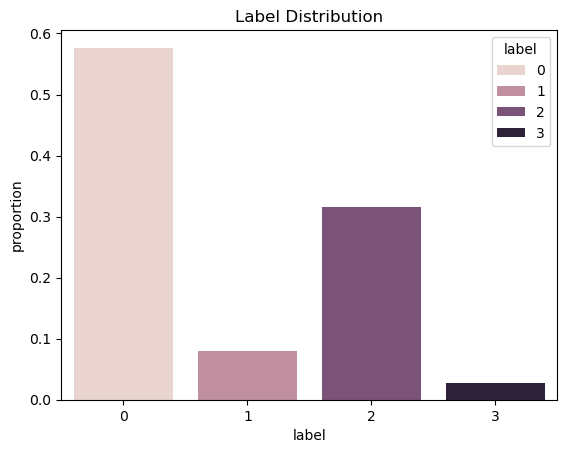

In [130]:
# label distribution

print(train['label'].value_counts(normalize=True))

l = train['label'].value_counts(normalize=True).reset_index()
sns.barplot(data=l, x='label', y='proportion', hue='label')
plt.title('Label Distribution')
plt.show()

**Dataset is highly imbalanced with almost 90 percent comprising of classes 0 and 2**

In [131]:
print(train.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

          emoticon_1     emoticon_2     emoticon_3         upvote  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        0.279768       0.048338       0.121071       2.607975   
std         1.023234       0.258477       0.481013       5.054763   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         0.000000       0.000000       0.000000       1.000000   
75%         0.000000       0.000000       0.000000       3.000000   
95%         2.000000       0.000000       1.000000      10.000000   
99%         4.000000       1.000000       2.000000      22.000000   
max        47.000000      11.000000      17.000000     201.000000   

            downvote           if_1           if_2          label  
count  198000.000000  198000.000000  198000.000000  198000.000000  
mean        0.666394       1.906152       7.956212       0.793965  
std         2.044335      25.635752 

**Each numeric Feature here Represents Count and Each of Them are right skewed. There are Outliers in each of them It can be a signal instead of a noise.**

- Most samples belong to lower classes (especially 0), making the dataset highly imbalanced.
- Upvotes and downvotes follow a long-tail distribution with few highly popular posts.
- keeping them is not a bad idea.

In [132]:
numeric_columns = [ col for col in train.columns if train[col].dtype in [int, float]]
categorical_columns = [col for col in train.columns if col not in numeric_columns]

In [133]:
print(numeric_columns)
print()
print(categorical_columns)

['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'label']

['created_date', 'race', 'religion', 'gender', 'disability', 'comment']


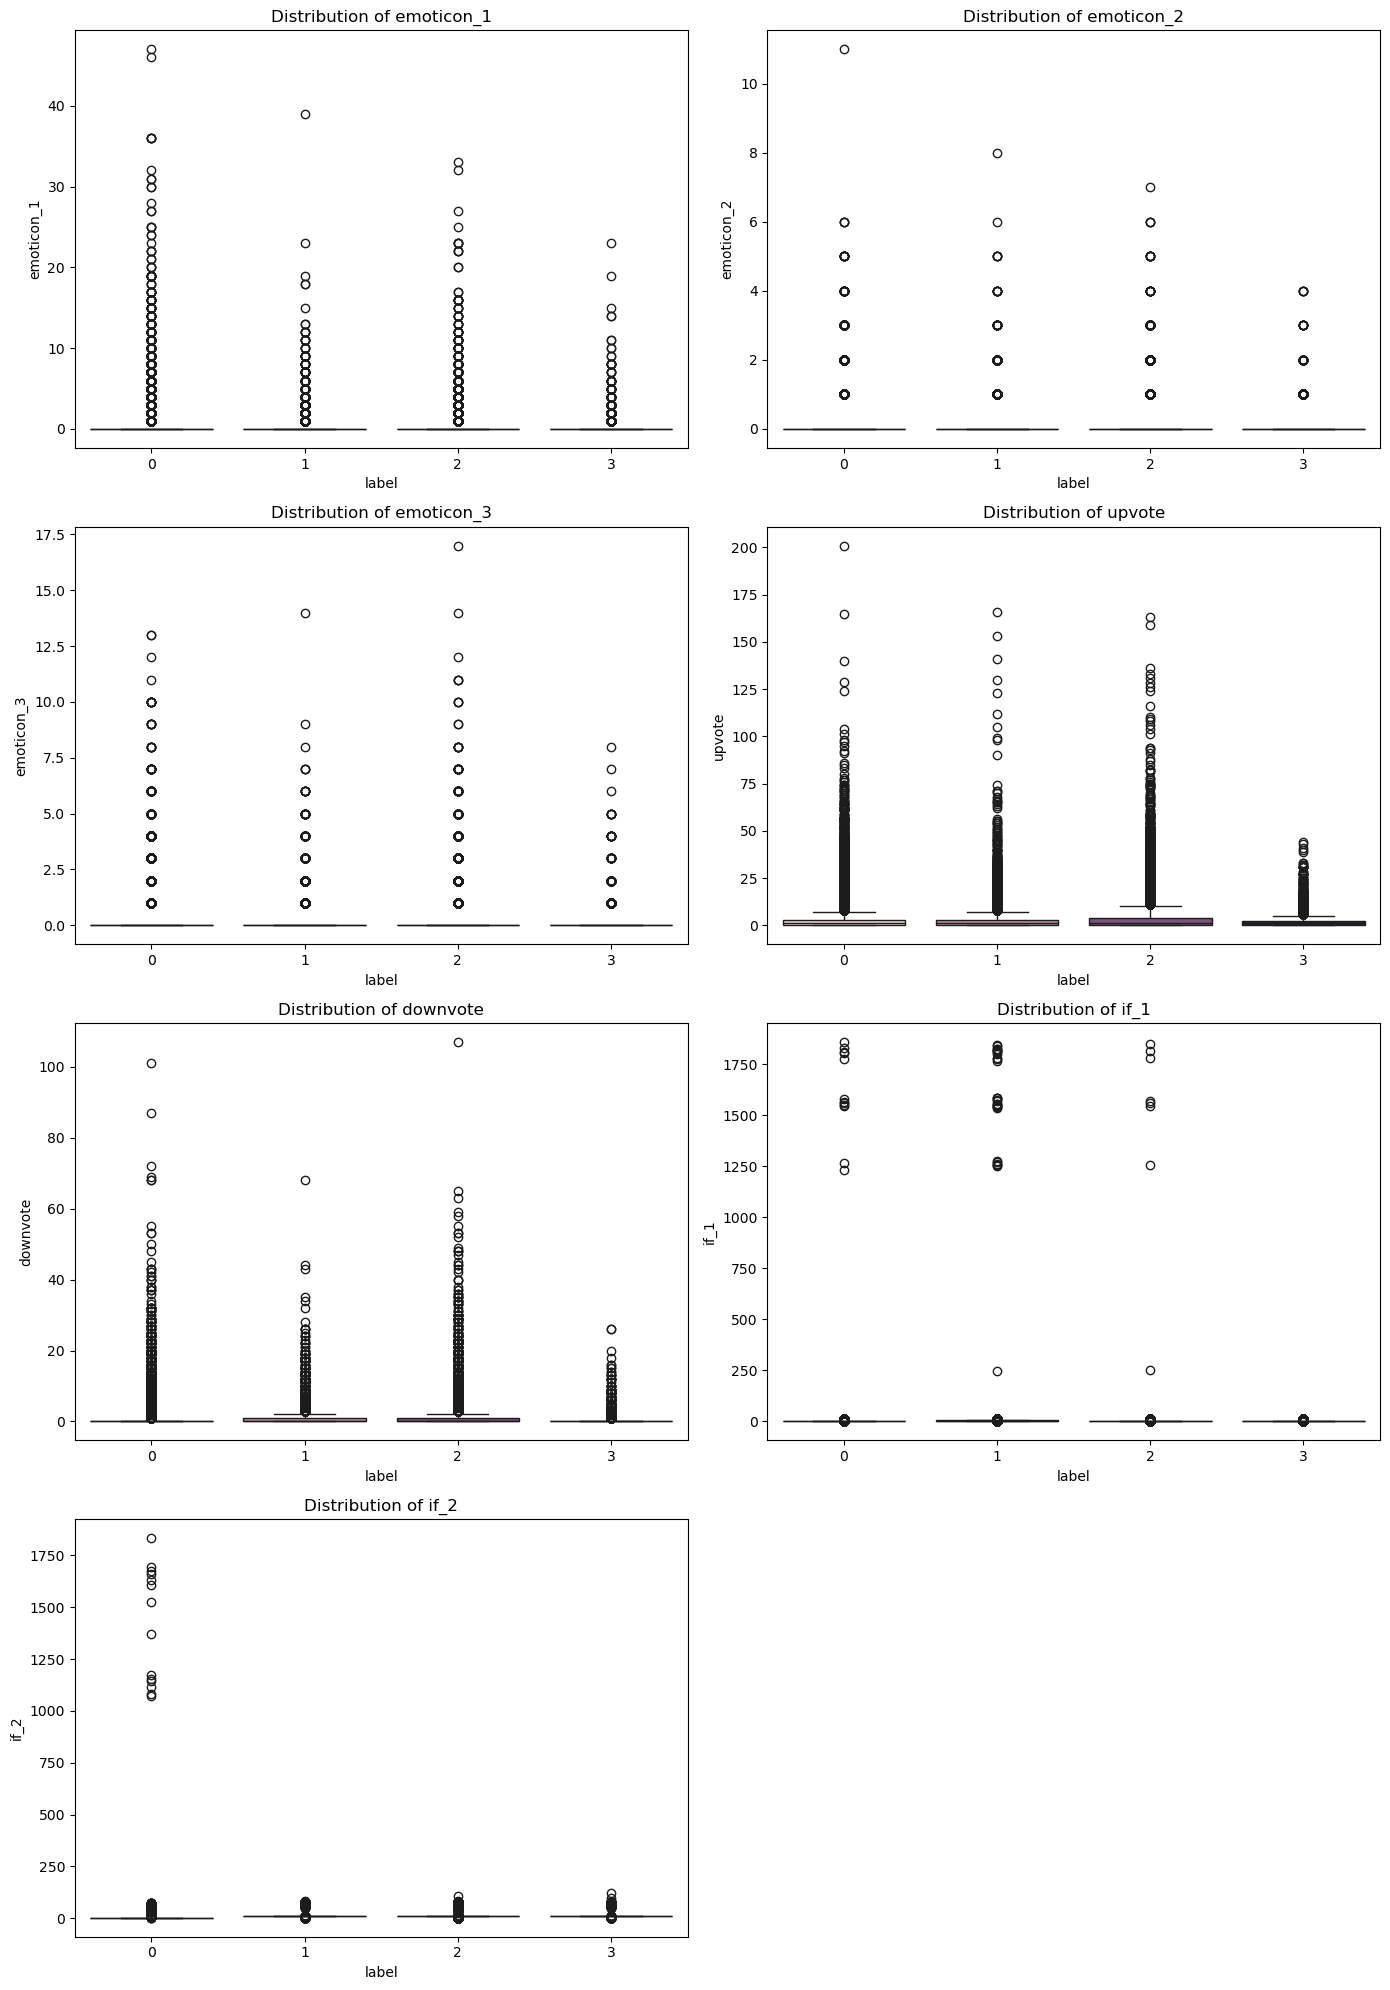

In [134]:
cols = [col for col in numeric_columns if col != 'label']
n = len(cols)
fig, axes = plt.subplots(nrows=(n + 1) // 2, ncols=2, figsize=(14, 5 * ((n + 1) // 2)))
axes = axes.flatten()

for idx, col in enumerate(cols):
    sns.boxplot(data=train, x='label', y=col, ax=axes[idx], hue='label', legend=False)
    axes[idx].set_title(f'Distribution of {col}')

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**From the Image It can be clearly seen that the Outliers of if_1 and if_2 are signals. Other feature's Outliers don't represent Strong signal**

## Exploring Categorical Features

In [ ]:
categorical_columns.remove('created_date')
categorical_columns.remove('comment')
for col in categorical_columns:
    print(f'{col} value counts:')
    print(train[col].value_counts())
    print()

created_date value counts:
created_date
2022-05-06 22:02:26.533945+00:00    2
2022-04-29 21:54:28.400339+00:00    2
2022-05-06 20:47:06.726636+00:00    2
2022-04-29 22:21:30.915678+00:00    2
2024-01-18 08:43:57.397508+00:00    1
                                   ..
2023-02-04 10:39:30.581185+00:00    1
2023-11-01 17:16:51.337370+00:00    1
2024-03-09 15:46:22.542539+00:00    1
2023-08-07 17:23:40.163756+00:00    1
2023-08-26 19:36:00.380158+00:00    1
Name: count, Length: 197996, dtype: int64

race value counts:
race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

religion value counts:
religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64

gender value counts:
gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: co

# Feature Extraction

## Create date time features

In [136]:
def create_datetime_features(df):
    df['year'] = df['created_date'].dt.year
    df['month'] = df['created_date'].dt.month
    df['day'] = df['created_date'].dt.day
    df['dayofweek'] = df['created_date'].dt.dayofweek
    df['quarter'] = df['created_date'].dt.quarter
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    return df

In [137]:
train['created_date'] = pd.to_datetime(train.created_date)
test['created_date'] = pd.to_datetime(test.created_date)

train = create_datetime_features(train)
test = create_datetime_features(test)

# drop the created_date column
train = train.drop('created_date', axis=1)
test = test.drop('created_date', axis=1)

## Text cleaning and Text Features

In [138]:
import re
# a function for cleaning the text data
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '<link>', text) # this removes the http links
    text = re.sub(r'www\.\S+', '<link>', text) # this removes the www links
    text = re.sub(r'https\S+', '<link>', text) # this removes the https links
    text = re.sub(r'\S+@\S+', '<email>', text) # this removes the email addresses
    text = re.sub(r'\d+', '<number>', text) # this removes the numbers
    return text

# dropna values before cleaning the text data
train = train.dropna(subset=['comment'])
test = test.dropna(subset=['comment'])

# apply the function to train and test data
train['comment_clean'] = train['comment'].apply(clean_text)
test['comment_clean'] = test['comment'].apply(clean_text)

In [139]:
for i in range(2):
    print(f'Original comment {i}:')
    print(train.comment[i])
    print(f'Cleaned comment {i}:')
    print(train.comment_clean[i])
    print()

Original comment 0:
She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.
Cleaned comment 0:
she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals.

Original comment 1:
Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically flip the bird to the tribal court and there's nothing they can actually do. The only courts it appears he is subject to are those formally established under state and federal law, which does not recognize this.

The tribal court can at-best basically use it's influence to get tribal members and others in the community to refuse to associate with Connor and not do business with him, essentially acting like a shunning until Connor decides to leave.
Cleaned comment 1:
under alaska law, a non-tribal member 

## Additional Text Features

In [140]:
# more textual features
def add_text_features(df):
    df['comment_len'] = df['comment'].str.len()
    df['comment_word_count'] = df['comment'].str.split().str.len().fillna(0)
    df['comment_avg_word_len'] = df['comment_len'] / (df['comment_word_count'] + 1)
    df['comment_upper_ratio'] = df['comment'].str.count(r'[A-Z]') / (df['comment_len'] + 1)
    df['comment_exclamation_count'] = df['comment'].str.count('!')
    df['comment_question_count'] = df['comment'].str.count(r'\?')
    df['comment_punct_count'] = df['comment'].str.count(r'[^\w\s]')
    df['comment_punct_ratio'] = df['comment_punct_count'] / (df['comment_len'] + 1)
    return df


In [141]:
train = add_text_features(train)
test = add_text_features(test)

## Create Val and Train set

In [142]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['label'])
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

print("Train label distribution")
print(y_train.value_counts() / len(y_train) * 100)

print("Validation label distribution")
print(y_val.value_counts() / len(y_val) * 100)

(158399, 27)
(39600, 27)
(158399,)
(39600,)
Train label distribution
label
0    57.663243
2    31.535553
1     8.039192
3     2.762012
Name: count, dtype: float64
Validation label distribution
label
0    57.661616
2    31.535354
1     8.040404
3     2.762626
Name: count, dtype: float64


In [143]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 158399 entries, 180416 to 66216
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   emoticon_1                 158399 non-null  int64  
 1   emoticon_2                 158399 non-null  int64  
 2   emoticon_3                 158399 non-null  int64  
 3   upvote                     158399 non-null  int64  
 4   downvote                   158399 non-null  int64  
 5   if_1                       158399 non-null  int64  
 6   if_2                       158399 non-null  int64  
 7   race                       41936 non-null   str    
 8   religion                   41936 non-null   str    
 9   gender                     41936 non-null   str    
 10  disability                 158399 non-null  bool   
 11  comment                    158399 non-null  str    
 12  year                       158399 non-null  int32  
 13  month                      158399 non-nul

In [144]:
X_train_text = X_train['comment_clean']
X_val_text = X_val['comment_clean']

X_train = X_train.drop(columns=['comment_clean', 'comment'])
X_val = X_val.drop(columns=['comment_clean', 'comment'])

In [145]:
bin_feature = ['disability']

numeric_features = [col for col in X_train.columns if X_train[col].dtype in ['int32','int64', float, *bin_feature]]

print(numeric_features, len(numeric_features))

categorical_features = [col for col in X_train.columns if col not in numeric_features and col not in bin_feature]

print(categorical_features, len(categorical_features))

print('total features', X_train.shape[1])

['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend', 'comment_len', 'comment_word_count', 'comment_avg_word_len', 'comment_upper_ratio', 'comment_exclamation_count', 'comment_question_count', 'comment_punct_count', 'comment_punct_ratio'] 21
['race', 'religion', 'gender'] 3
total features 25


## Vectorizing text

In [146]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000,
                        stop_words='english',
                        lowercase=True,
                        min_df=5,
                        )

X_train_text_counts = tfidf.fit_transform(X_train_text)
X_val_text_counts = tfidf.transform(X_val_text)


## Preprocessing using Pipeline

In [147]:
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# apply sequential transformations to the categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True,))
])

# poly = PolynomialFeatures(degree=2, interaction_only=True)

# apply transformations on the numeric and categorical features in one go
preprocessor = ColumnTransformer([
    # ('num', poly, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='passthrough')

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)

X_train_prep = X_train_prep.astype(np.float32)
X_val_prep = X_val_prep.astype(np.float32)

In [148]:
preprocessor.get_feature_names_out()

array(['cat__race_asian', 'cat__race_black', 'cat__race_latino',
       'cat__race_none', 'cat__race_other', 'cat__race_white',
       'cat__religion_atheist', 'cat__religion_buddhist',
       'cat__religion_christian', 'cat__religion_hindu',
       'cat__religion_jewish', 'cat__religion_muslim',
       'cat__religion_none', 'cat__religion_other', 'cat__gender_female',
       'cat__gender_male', 'cat__gender_none', 'cat__gender_other',
       'cat__gender_transgender', 'remainder__emoticon_1',
       'remainder__emoticon_2', 'remainder__emoticon_3',
       'remainder__upvote', 'remainder__downvote', 'remainder__if_1',
       'remainder__if_2', 'remainder__disability', 'remainder__year',
       'remainder__month', 'remainder__day', 'remainder__dayofweek',
       'remainder__quarter', 'remainder__is_weekend',
       'remainder__comment_len', 'remainder__comment_word_count',
       'remainder__comment_avg_word_len',
       'remainder__comment_upper_ratio',
       'remainder__comment_excla

In [149]:
from scipy.sparse import hstack, csr_matrix

X_train_final = hstack([csr_matrix(X_train_prep), X_train_text_counts])
X_val_final = hstack([csr_matrix(X_val_prep), X_val_text_counts])


In [150]:
from sklearn.metrics import classification_report, confusion_matrix
def evaluate(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    print('Train Classification Report:')
    print(confusion_matrix(y_train, train_pred))
    print(classification_report(y_train, train_pred))
    print()
    print('Validation Classification Report:')
    print(confusion_matrix(y_val, val_pred))
    print(classification_report(y_val, val_pred))

# Model building and fietuning

In [160]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

grid_params = {
    'learning_rate': [0.1, 0.2, 0.3, 0.4],
    'num_leaves': [31, 50],
    'max_depth': [10, 12, 15],
    'reg_alpha': [0.0, 0.5, 1.0],
    'reg_lambda': [0.0, 1.0, 5.0],
    'min_split_gain': [0.0, 0.1, 0.3],
    'min_child_samples': [20, 30, 50],
    'min_child_weight': [1e-3, 1e-2, 1e-1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


model = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    n_estimators=200,
    subsample_freq=1
)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=grid_params,
    n_iter=50,
    scoring='f1_macro',
    cv=2,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_final, y_train)

print(random_search.best_params_)
print(random_search.best_score_)


Fitting 2 folds for each of 50 candidates, totalling 100 fits


KeyboardInterrupt: 

In [154]:
fi = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out().tolist() + tfidf.get_feature_names_out().tolist(),
    'importance': model.feature_importances_.tolist()
}).sort_values(by='importance', ascending=False)
print(fi.head(50))

                                    feature  importance
35          remainder__comment_avg_word_len         577
40           remainder__comment_punct_ratio         516
36           remainder__comment_upper_ratio         504
29                           remainder__day         418
33                   remainder__comment_len         322
28                         remainder__month         265
25                          remainder__if_2         250
34            remainder__comment_word_count         228
39           remainder__comment_punct_count         223
22                        remainder__upvote         214
30                     remainder__dayofweek         184
24                          remainder__if_1         137
9792                                   kill         118
12906                                people         100
12009                                number          91
19551                                 white          89
18377                                 trump     